In [1]:
import os
# from google.colab import files
os.environ.update(comspec="powershell.exe")

In [2]:
import torch

# Check if a GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"Using device: {torch.cuda.get_device_name(device)}")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: NVIDIA GeForce RTX 3060


### Setup Kaggle API

In [3]:
# # setup the kaggle API

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600  ~/.kaggle/kaggle.json

# print("Kaggle setup complete")

In [4]:
# !pip install kaggle

In [3]:
# check kaggle API
!kaggle datasets list --max 10

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aryan208/student-habits-and-academic-performance-dataset           Student Habits and Academic Performance Dataset        2994172  2025-05-02 00:27:34.627000           3515         40  1.0              
novandraanugrah/bitcoin-historical-datasets-2018-2024              BITCOIN Historical Datasets 2018-2025 Binance API     18466138  2025-06-13 02:06:49.420000           9913         93  0.8235294        
mayasixtine/prix-nc-datasets-historises                            Prix.nc - Datasets historisés                         44216191  2025-06-12 04:00:48.413000             93          2  0.8

### Download the BraTS20 Dataset from Kaggle

In [4]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
 99% 4.14G/4.16G [01:34<00:00, 34.4MB/s]
100% 4.16G/4.16G [01:34<00:00, 47.1MB/s]


In [5]:
print("Unzipping dataset")
!unzip -q brats20-dataset-training-validation.zip
print("Unzipping complete")

Unzipping dataset
Unzipping complete


In [ ]:
!ls -l BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/


In [7]:
!rm brats20-dataset-training-validation.zip # removing to save colab space
!ls -l

total 16
drwxr-xr-x 3 root root 4096 Jun 11 19:43 BraTS2020_TrainingData
drwxr-xr-x 3 root root 4096 Jun 11 19:50 BraTS2020_ValidationData
-rw-r--r-- 1 root root   73 Jun 11 19:38 kaggle.json
drwxr-xr-x 1 root root 4096 Jun 10 13:39 sample_data


### Imports

In [4]:
import torch
import torch.nn.functional as F
import nibabel as nib
import numpy as np
import glob
import cv2
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMScheduler, UNet2DModel, AutoencoderKL

from accelerate import Accelerator
from PIL import Image
import matplotlib.pyplot as plt


### Preprocessing the data

In [10]:
!ls



    Directory: C:\Users\Wasiq\Desktop\Latency_Diffusion_Model


Mode                 LastWriteTime         Length Name                                                                 
----                 -------------         ------ ----                                                                 
d-----         6/12/2025   4:31 PM                .ipynb_checkpoints                                                   
d-----         6/12/2025   4:23 PM                BraTS2020_TrainingData                                               
d-----         6/12/2025   4:25 PM                BraTS2020_ValidationData                                             
-a----         6/12/2025   4:39 PM        2516200 latent_diffusion_brats.ipynb                                         




In [5]:
# preprocessing the 3D scans into 2D slices

BASE_DIR = "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
PROC_DIR_IMG = "processed_data/images"
PROC_DIR_MASK = "processed_data/masks"

os.makedirs(PROC_DIR_IMG, exist_ok=True)
os.makedirs(PROC_DIR_MASK, exist_ok=True)

In [6]:
IMG_SIZE = 128 # scale to 128x128
SAMPLE_SIZE = 100 # smaller sample size for Colab (set this to a higher number to process full dataset)
SLICE_THRESHOLD = 0.001 # filter out empty slices

In [7]:
patient_dirs = sorted(glob.glob(os.path.join(BASE_DIR, "BraTS20*")))
patient_dirs_to_process = patient_dirs[:SAMPLE_SIZE]

In [8]:
len(patient_dirs)

369

In [9]:
patient_dirs_to_process

['BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_001',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_002',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_003',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_004',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_005',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_006',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_007',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_008',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_009',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_010',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_011',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData\\BraTS20_Training_012',
 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingDa

In [10]:
print(f'Starting preprocessing for {len(patient_dirs_to_process)} patients')

Starting preprocessing for 100 patients


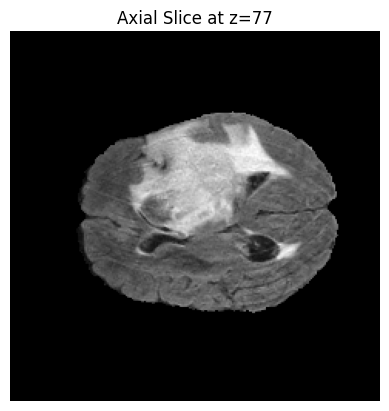

In [23]:
# Testing and displaying the data
p_id = patient_dirs_to_process[0]
f_path = glob.glob(os.path.join(p_id, "*_flair.nii"))[0]
f_img = nib.load(f_path).get_fdata()
z_slice = f_img.shape[2] // 2

# Plot the slice
plt.imshow(f_img[:, :, z_slice], cmap='gray')
plt.title(f'Axial Slice at z={z_slice}')
plt.axis('off')
plt.show()

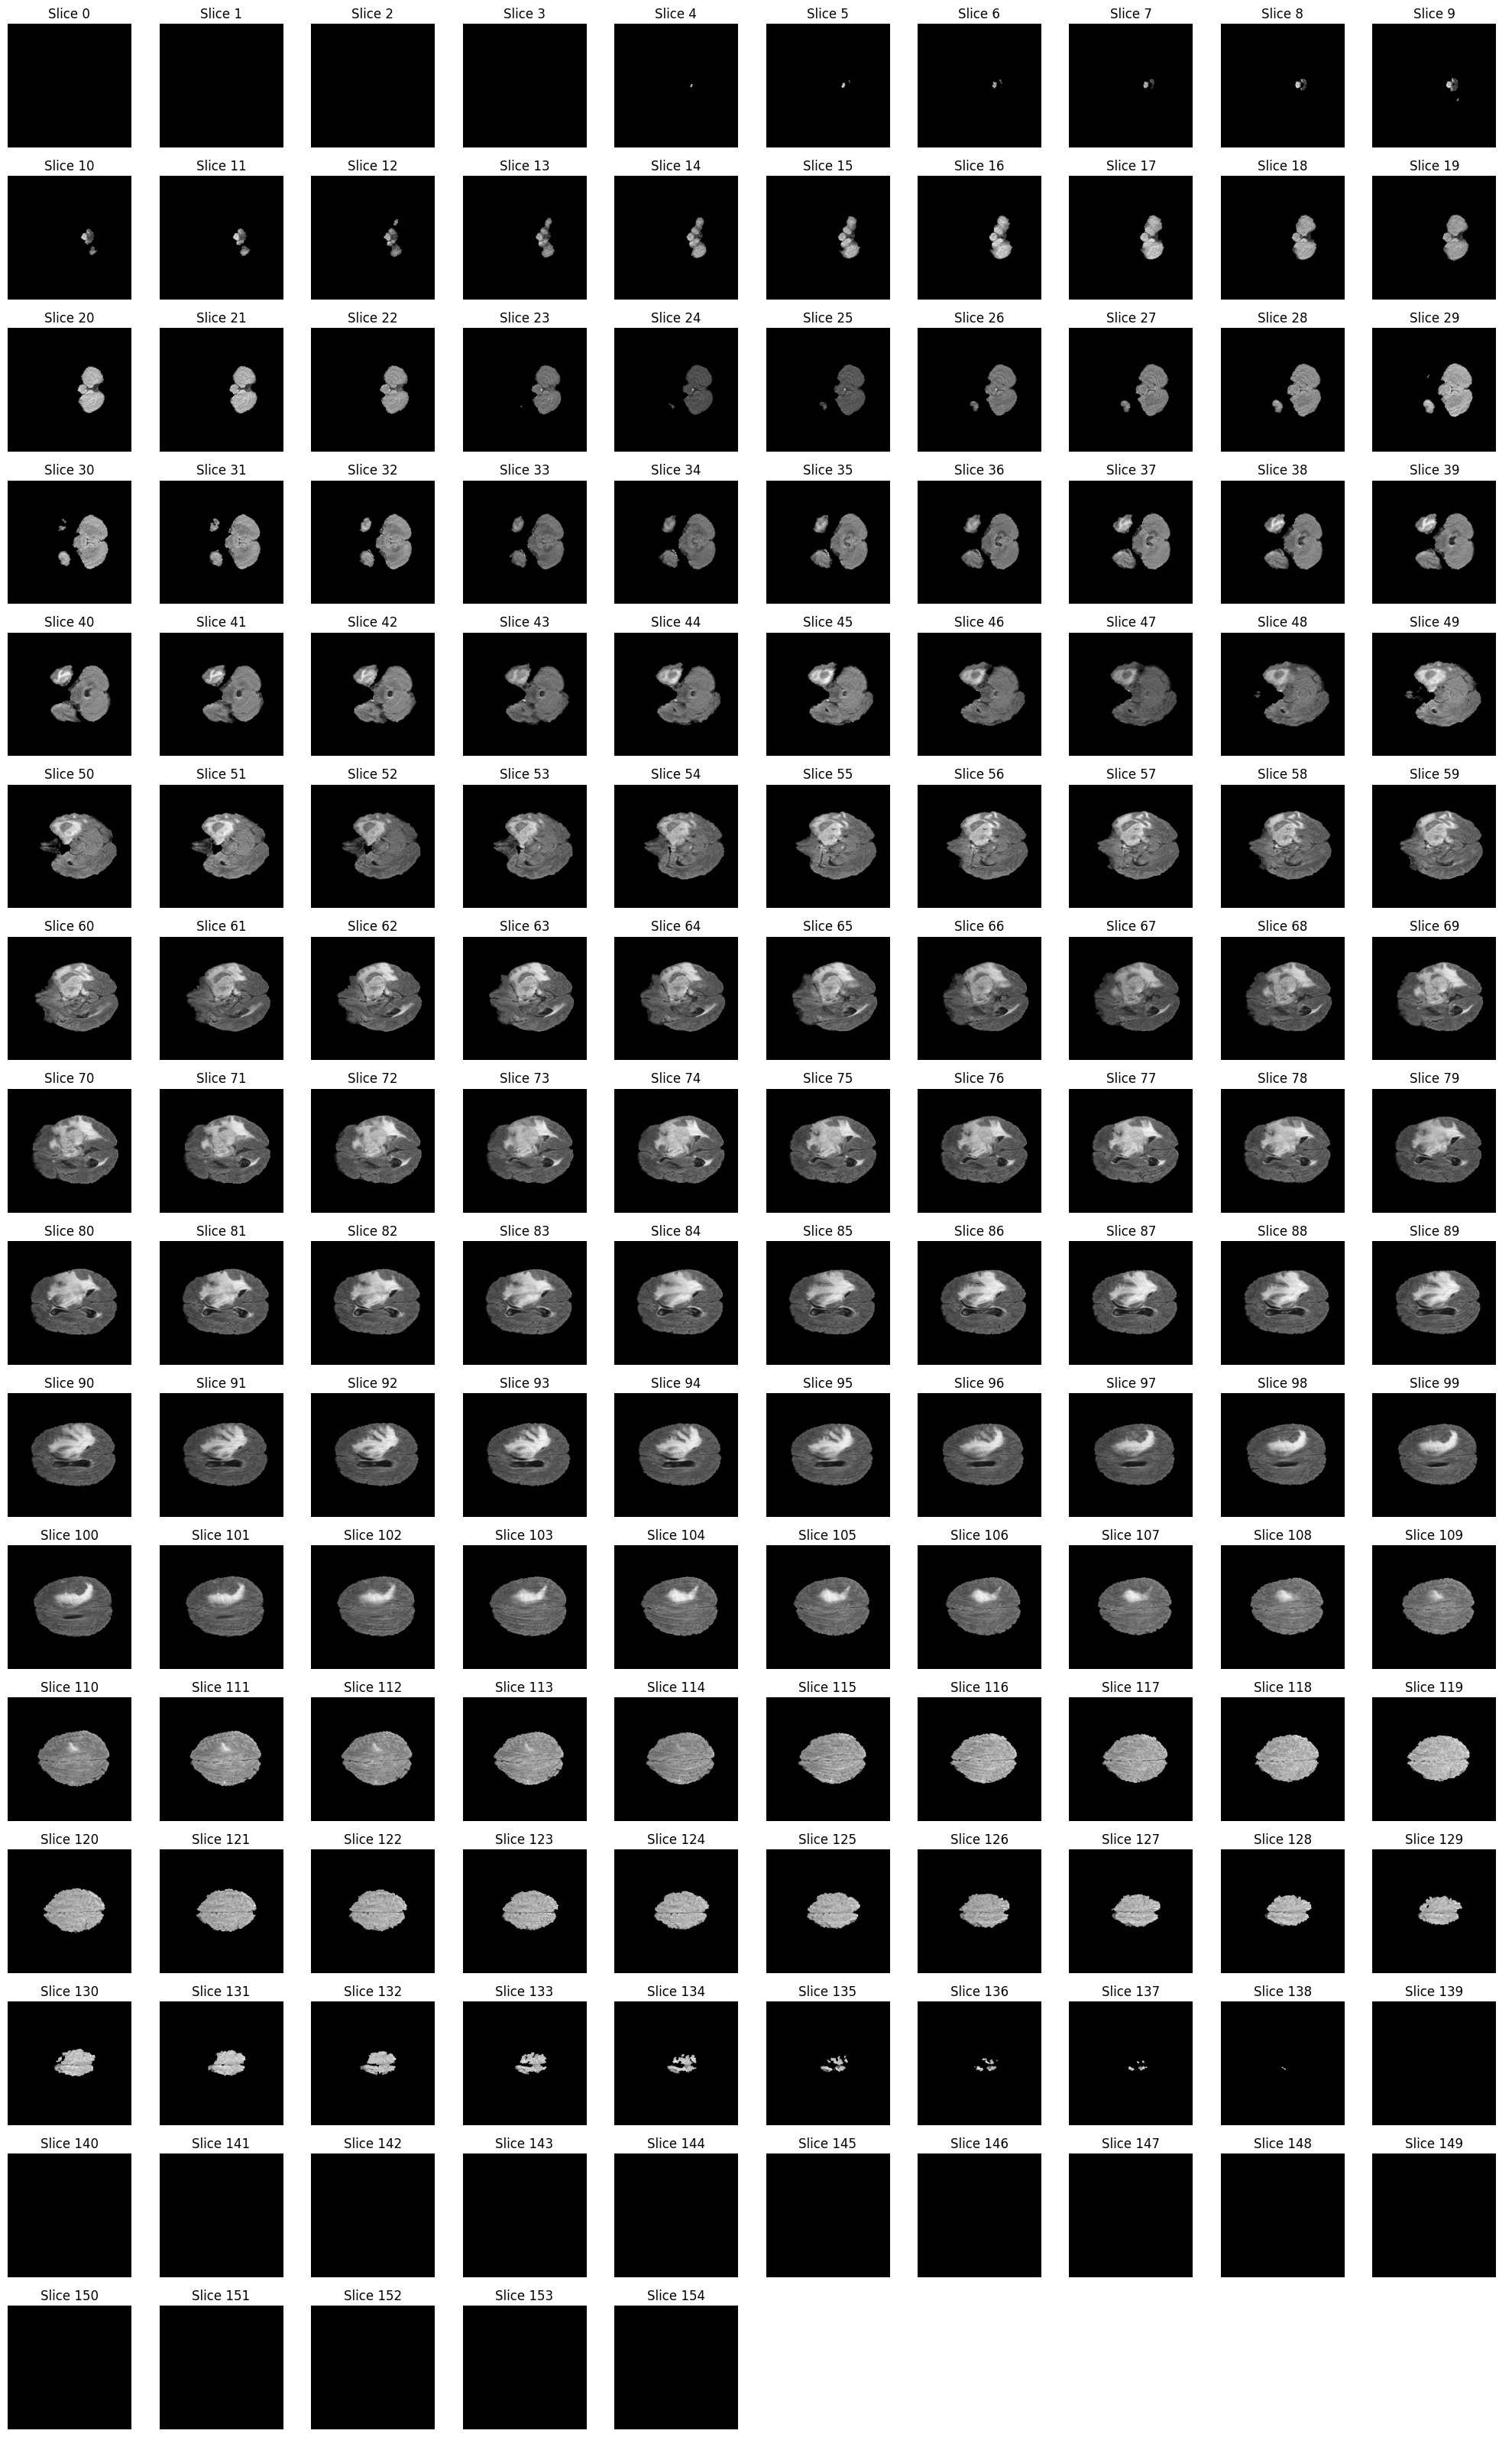

In [26]:
num_slices = f_img.shape[2]

# Define grid size (e.g. 10 columns, rows auto)
cols = 10
rows = num_slices // cols + int(num_slices % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2))
axes = axes.flatten()

for i in range(num_slices):
    axes[i].imshow(f_img[:, :, i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Slice {i}')

# Turn off any extra subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
slice_counter = 0

for patient_dir in tqdm(patient_dirs_to_process, desc="Preprocessing"):
  patient_id = os.path.basename(patient_dir)
  try:
    flair_path = glob.glob(os.path.join(patient_dir, "*_flair.nii"))[0]
    t1_path = glob.glob(os.path.join(patient_dir, "*_t1.nii"))[0]
    t1ce_path = glob.glob(os.path.join(patient_dir, "*_t1ce.nii"))[0]
    t2_path = glob.glob(os.path.join(patient_dir, "*_t2.nii"))[0]
    seg_path = glob.glob(os.path.join(patient_dir, "*_seg.nii"))[0]

    flair_img = nib.load(flair_path).get_fdata()
    t1_img = nib.load(t1_path).get_fdata()
    t1ce_img = nib.load(t1ce_path).get_fdata()
    t2_img = nib.load(t2_path).get_fdata()
    seg_img = nib.load(seg_path).get_fdata()
  except IndexError:
    print(f"Skipping patient {patient_id}: missing files.")
    continue

# filtering slices based on threshold
  for i in range(flair_img.shape[2]):
    mask_slice = seg_img[:, :, i].astype(np.uint8)
    mask_slice[mask_slice > 0] = 1
    # resizing
    if np.sum(mask_slice) > (IMG_SIZE * IMG_SIZE * SLICE_THRESHOLD):
      flair_slice = cv2.resize(flair_img[:, :, i], (IMG_SIZE, IMG_SIZE))
      t1ce_slice = cv2.resize(t1ce_img[:,:,i], (IMG_SIZE, IMG_SIZE))
      t2_slice = cv2.resize(t2_img[:, :, i], (IMG_SIZE, IMG_SIZE))

      # normalize to [0,1]
      flair_slice = (flair_slice - np.min(flair_slice)) / (np.max(flair_slice) - np.min(flair_slice) + 1e-6)
      t1ce_slice = (t1ce_slice - np.min(t1ce_slice)) / (np.max(t1ce_slice) - np.min(t1ce_slice) + 1e-6)
      t2_slice = (t2_slice - np.min(t2_slice)) / (np.max(t2_slice) - np.min(t2_slice) + 1e-6)

      # stack the slices
      combined_slice = np.stack([flair_slice, t1ce_slice, t2_slice], axis=0).astype(np.float32)

      # resize the mask
      mask_slice_resized = cv2.resize(mask_slice, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
      mask_slice_resized = mask_slice_resized.astype(np.uint8)

      # convert to PyTorch tensors
      torch_image = torch.from_numpy(combined_slice)
      torch_mask = torch.from_numpy(mask_slice_resized).unsqueeze(0)

      # save the tensors
      torch.save(torch_image, os.path.join(PROC_DIR_IMG, f"slice_{slice_counter}.pt"))
      torch.save(torch_mask, os.path.join(PROC_DIR_MASK, f"slice_{slice_counter}.pt"))

      slice_counter += 1

print(f"Processing complete for {slice_counter} non-empty slices")
# !ls -l processed_data/images | head -n 5
# !ls -l processed_data/masks | head -n -5



Preprocessing:   0%|          | 0/100 [00:00<?, ?it/s]

Processing complete for 6210 non-empty slices


In [11]:
slice_counter

6210

In [12]:
print("\n--- Setting up the Dataset ---")
class BraTSDataset(Dataset):
    def __init__(self, image_dir):
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.pt")))
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        image_tensor = torch.load(self.image_files[idx])
        return (image_tensor * 2.0) - 1.0

# Ensure you have processed the full dataset in Step 3
PROCESSED_DIR_IMG = "processed_data/images"
dataset = BraTSDataset(PROCESSED_DIR_IMG)
print(f"Dataset created with {len(dataset)} slices.")


# Part 3: Training Configuration (with new parameters)
print("\n--- Configuring Training Parameters ---")
config = {
    "image_size": 128,
    "batch_size": 16, # The batch size you found works on your 3060
    "num_epochs": 30, # Train for a substantial number of epochs
    "unet_learning_rate": 1e-4,
    "vae_learning_rate": 1e-6,  # NEW: A much smaller LR for the VAE
    "reconstruction_loss_weight": 0.5, # NEW: How much to weigh the VAE's loss
    "save_model_epochs": 5,
    "output_dir": "diffusion_model_brats_finetuned"
}
os.makedirs(config["output_dir"], exist_ok=True)


# Part 4: Configure LDM Components
print("\n--- Configuring LDM Components (U-Net, VAE, Scheduler) ---")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
model = UNet2DModel(
    sample_size=config["image_size"] // 8, in_channels=4, out_channels=4,
    layers_per_block=2, block_out_channels=(128, 256, 512, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
)
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)


# Part 5: The Training Loop (Modified for Fine-Tuning)
print("\n--- Starting the Training Process with VAE Fine-Tuning ---")
train_dataloader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True)
accelerator = Accelerator(mixed_precision="fp16")

# --- NEW: Optimizer with two parameter groups ---
# We give the VAE parameters a different (smaller) learning rate
optimizer = torch.optim.AdamW([
    {'params': model.parameters(), 'lr': config["unet_learning_rate"]},
    {'params': vae.parameters(), 'lr': config["vae_learning_rate"]}
])

# Prepare all components with the accelerator
model, vae, optimizer, train_dataloader = accelerator.prepare(
    model, vae, optimizer, train_dataloader
)

# Training loop
for epoch in range(config["num_epochs"]):
    progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}")
    # --- NEW: Set both models to training mode ---
    model.train()
    vae.train()

    for step, batch in enumerate(train_dataloader):
        # The VAE requires float32 inputs for its convolution layers
        batch_fp32 = batch.to(torch.float32)

        # --- NEW: VAE Forward Pass and Reconstruction Loss ---
        # Reconstruct the image to calculate reconstruction loss
        reconstructed_images = vae(batch_fp32).sample
        reconstruction_loss = F.mse_loss(reconstructed_images, batch_fp32)

        # Now, proceed with the diffusion process
        with torch.no_grad():
            latents = vae.encode(batch_fp32).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device)
        # Add noise to the latents using the mixed-precision latents
        noisy_latents = noise_scheduler.add_noise(latents.to(torch.float16), noise.to(torch.float16), timesteps)

        # Get the U-Net's prediction for the noise
        noise_pred = model(noisy_latents, timesteps).sample

        # Calculate the two losses
        diffusion_loss = F.mse_loss(noise_pred, noise)
        total_loss = diffusion_loss + config["reconstruction_loss_weight"] * reconstruction_loss

        # Backpropagate the total loss
        accelerator.backward(total_loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        progress_bar.set_postfix(loss=total_loss.item(), diff_loss=diffusion_loss.item(), vae_loss=reconstruction_loss.item())

    # After each epoch, save both models
    if (epoch + 1) % config["save_model_epochs"] == 0 or epoch == config["num_epochs"] - 1:
        print(f"\nSaving models at epoch {epoch+1}...")
        # Unwrap models to save the raw state dict
        unwrapped_unet = accelerator.unwrap_model(model)
        unwrapped_vae = accelerator.unwrap_model(vae)
        torch.save(unwrapped_unet.state_dict(), os.path.join(config["output_dir"], f"unet_epoch_{epoch+1}.pt"))
        # --- NEW: Also save the fine-tuned VAE ---
        unwrapped_vae.save_pretrained(os.path.join(config["output_dir"], f"vae_epoch_{epoch+1}"))


print("\n--- Training Complete ---")
print(f"Final models saved in: {config['output_dir']}")



--- Setting up the Dataset ---
Dataset created with 19094 slices.

--- Configuring Training Parameters ---

--- Configuring LDM Components (U-Net, VAE, Scheduler) ---

--- Starting the Training Process with VAE Fine-Tuning ---


Epoch 1:   0%|          | 0/1194 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# --- Part 2: Create a PyTorch Dataset ---
print("\n--- Setting up the Dataset ---")

class BraTSDataset(Dataset):
    def __init__(self, image_dir):
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.pt")))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_tensor = torch.load(self.image_files[idx])
        return (image_tensor * 2.0) - 1.0

PROCESSED_DIR_IMG = "processed_data/images"
dataset = BraTSDataset(PROCESSED_DIR_IMG)
print(f"Dataset created with {len(dataset)} slices.")


# --- Part 3: Training Configuration ---
print("\n--- Configuring Training Parameters ---")
config = {
    "image_size": 128,
    "batch_size": 64,
    "num_epochs": 50,
    "learning_rate": 1e-4,
    "save_model_epochs": 10,
    "output_dir": "diffusion_model_brats"
}
os.makedirs(config["output_dir"], exist_ok=True)


# --- Part 4: Configure LDM Components (Corrected U-Net Architecture) ---
print("\n--- Configuring LDM Components (U-Net, VAE, Scheduler) ---")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=torch.float16)

# --- CORRECTED U-NET DEFINITION ---
# This U-Net is shallower, making it compatible with our 16x16 latent space.
# We now have 4 down/up blocks instead of 6.
model = UNet2DModel(
    sample_size=config["image_size"] // 8,  # 16
    in_channels=4,
    out_channels=4,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),  # 4 levels
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)
# --- END OF CORRECTION ---

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)


# --- Part 5: The Training Loop ---
print("\n--- Starting the Training Process ---")
train_dataloader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True)

accelerator = Accelerator(mixed_precision="fp16")
vae.to(accelerator.device)
vae.eval()

optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

model, optimizer, train_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader
)

vae.to(torch.float32)

for epoch in range(config["num_epochs"]):
    progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}")
    model.train()

    for step, batch in enumerate(train_dataloader):
        batch = batch.to(torch.float32)

        with torch.no_grad():
            latents = vae.encode(batch).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        noise_pred = model(noisy_latents, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        progress_bar.set_postfix(loss=loss.item())

    if (epoch + 1) % config["save_model_epochs"] == 0 or epoch == config["num_epochs"] - 1:
        print(f"\nSaving model at epoch {epoch+1}...")
        unwrapped_model = accelerator.unwrap_model(model)
        torch.save(unwrapped_model.state_dict(), os.path.join(config["output_dir"], f"unet_brats_epoch_{epoch+1}.pt"))

print("\n--- Training Complete ---")
print(f"Final model saved in: {config['output_dir']}")

In [11]:
print("hi")

hi


Configuring Generation Parameters
--- Loading Trained Models (U-Net and VAE) ---
--- Starting Generation of 1 Images ---


Generating Batches:   0%|          | 0/1 [00:00<?, ?it/s]


--- Generation Complete ---
1 synthetic images saved to: synthetic_data/images

--- Displaying a Sample Generated Image ---


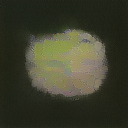

In [19]:

print("Configuring Generation Parameters")
config = {

    "unet_weights_path": "diffusion_model_brats/unet_brats_epoch_15.pt",
    "output_dir": "synthetic_data/images",
    "num_images": 1,          # How many images you want to generate.
    "batch_size": 1,           # How many images to generate at once.
    "image_size": 128
}

# Create the output directory if it doesn't exist
os.makedirs(config["output_dir"], exist_ok=True)


#  Load Models
print("--- Loading Trained Models (U-Net and VAE) ---")
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-create the U-Net and VAE with the same architecture as in training
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)

model = UNet2DModel(
    sample_size=config["image_size"] // 8,
    in_channels=4, out_channels=4,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

# Load the trained weights into the U-Net
model.load_state_dict(torch.load(config["unet_weights_path"], map_location=device))
model.eval() # Set model to evaluation mode
vae.eval()   # Set VAE to evaluation mode

# Create the noise scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000)


# --- Part 3: Generation (Inference) Loop ---
print(f"--- Starting Generation of {config['num_images']} Images ---")
# Use torch.no_grad() to disable gradient calculations for efficiency
with torch.no_grad():
    # Calculate the number of batches needed
    num_batches = int(np.ceil(config["num_images"] / config["batch_size"]))

    # Keep track of the total number of images saved
    saved_count = 0

    for i in tqdm(range(num_batches), desc="Generating Batches"):
        # Determine the batch size for this iteration (handles the last partial batch)
        current_batch_size = min(config["batch_size"], config["num_images"] - saved_count)
        if current_batch_size <= 0:
            continue

        # 1. Start with random noise in the latent space
        latents = torch.randn(
            (current_batch_size, model.config.in_channels, model.config.sample_size, model.config.sample_size),
            device=device
        )

        # 2. Set the scheduler's timesteps for the denoising loop
        scheduler.set_timesteps(1000)

        # 3. Iteratively denoise the latents
        for t in scheduler.timesteps:
            # Predict the noise for the current latents
            noise_pred = model(latents, t).sample
            # Use the scheduler to compute the previous, less noisy latent state
            latents = scheduler.step(noise_pred, t, latents).prev_sample

        # 4. Decode the final latents back into pixel space
        latents = 1 / vae.config.scaling_factor * latents
        images = vae.decode(latents).sample

        # 5. Post-process and save the images
        # Convert from [-1, 1] to [0, 1] range
        images = (images / 2.0) + 0.5
        images.clamp_(0, 1) # Clamp values to be safe

        # Save each image in the batch individually
        for image_tensor in images:
            torch.save(image_tensor.cpu(), os.path.join(config["output_dir"], f"synthetic_slice_{saved_count}.pt"))
            saved_count += 1

print(f"\n--- Generation Complete ---")
print(f"{saved_count} synthetic images saved to: {config['output_dir']}")


# --- Part 4: Visualize a Sample ---
print("\n--- Displaying a Sample Generated Image ---")
# Load one of the saved tensors
sample_path = glob.glob(os.path.join(config["output_dir"], "*.pt"))[0]
sample_tensor = torch.load(sample_path)

# Convert tensor to numpy array for visualization
# The tensor is (C, H, W), we need (H, W, C) for PIL
sample_np = sample_tensor.permute(1, 2, 0).numpy()

# Scale to 0-255 for image format
sample_np = (sample_np * 255).round().astype(np.uint8)

# Create and display PIL image
pil_image = Image.fromarray(sample_np)
pil_image.save(os.path.join(config["output_dir"], f"synthetic_slice_{saved_count}.png"))
display(pil_image)

In [13]:
# --- Part 4: Visualize a Sample ---
print("\n--- Displaying a Sample Generated Image ---")
# Load one of the saved tensors
sample_path = glob.glob(os.path.join(config["output_dir"], "*.pt"))[10]
sample_tensor = torch.load(sample_path)

# Convert tensor to numpy array for visualization
# The tensor is (C, H, W), we need (H, W, C) for PIL
sample_np = sample_tensor.permute(1, 2, 0).numpy()

# Scale to 0-255 for image format
sample_np = (sample_np * 255).round().astype(np.uint8)

# Create and display PIL image
pil_image = Image.fromarray(sample_np)
display(pil_image)


--- Displaying a Sample Generated Image ---


IndexError: list index out of range

Loading the pre-trained VAE...
Loading original image: processed_data/images\slice_10012.pt
Reconstructing image through VAE (Encode -> Decode)...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16327912..0.87169445].


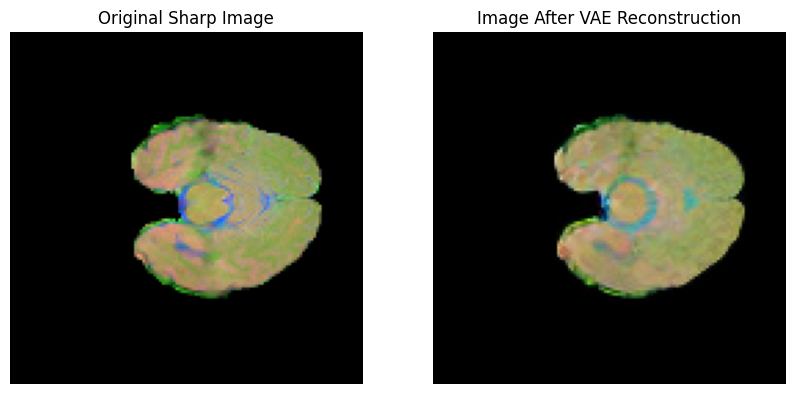

In [18]:
# --- Configuration ---
# Path to one of your original, preprocessed training images
# NOTE: This should be from your "processed_data/images" folder from Step 3
try:
    original_image_path = glob.glob("processed_data/images/*.pt")[18]
except IndexError:
    print("Error: Could not find any processed images in 'processed_data/images/'.")
    print("Please ensure you have run the Step 3 preprocessing script.")
    original_image_path = None

if original_image_path:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Load the VAE ---
    print("Loading the pre-trained VAE...")
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
    vae.eval()

    # --- Load and Prepare Original Image ---
    print(f"Loading original image: {original_image_path}")
    # Load the tensor and add a batch dimension (B, C, H, W)
    image_tensor = torch.load(original_image_path).unsqueeze(0).to(device)
    # Convert from our [0, 1] range to the VAE's expected [-1, 1] range
    image_tensor = (image_tensor * 2.0) - 1.0

    # --- Perform Reconstruction ---
    print("Reconstructing image through VAE (Encode -> Decode)...")
    with torch.no_grad():
        # Encode the image to get its latent representation
        latent_dist = vae.encode(image_tensor).latent_dist
        latents = latent_dist.sample()
        # Decode the latents to get the reconstructed image
        reconstructed_image = vae.decode(latents).sample

    # --- Prepare images for display ---
    # Convert original image from [-1, 1] back to [0, 1] for display
    original_for_display = (image_tensor.cpu().squeeze(0) / 2.0) + 0.5
    original_np = original_for_display.permute(1, 2, 0).numpy()

    # Convert reconstructed image from [-1, 1] back to [0, 1] for display
    reconstructed_for_display = (reconstructed_image.cpu().squeeze(0) / 2.0) + 0.5
    reconstructed_np = reconstructed_for_display.permute(1, 2, 0).numpy()


    # --- Display side-by-side ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_np)
    axes[0].set_title("Original Sharp Image")
    axes[0].axis("off")

    axes[1].imshow(reconstructed_np)
    axes[1].set_title("Image After VAE Reconstruction")
    axes[1].axis("off")

    plt.show()
